In [ ]:
impor  numpy  sebagai  np
impor  panda  sebagai  pd
impor  matplotlib.pyplot  sebagai  plt
impor  seaborn  sebagai  sns

In [ ]:
#Load Data
df = pd.read_csv('Realestate.csv')
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [ ]:
#Informasi data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [ ]:
#Deskripsi data
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [ ]:
#Cek Korelasi
df.corr()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,1.000000,-0.048658,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
X1 transaction date,-0.048658,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
X2 house age,-0.032808,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,-0.012699,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,-0.010110,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.011059,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,-0.028587,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


In [ ]:
#Cek Nilai Null
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

<Axes: >

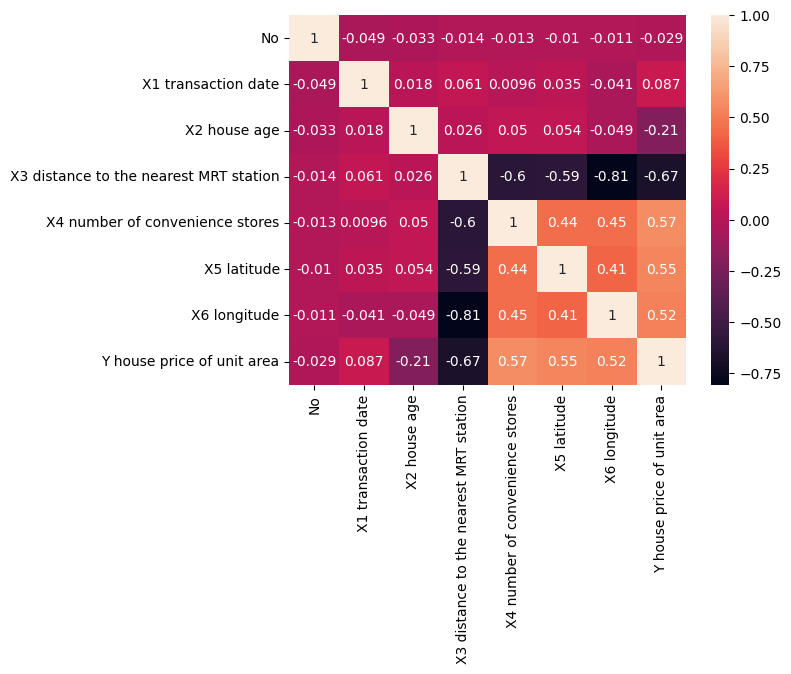

In [ ]:
#Korelasi Heatmap
sns.heatmap(df.corr(), annot= True)

<Axes: >

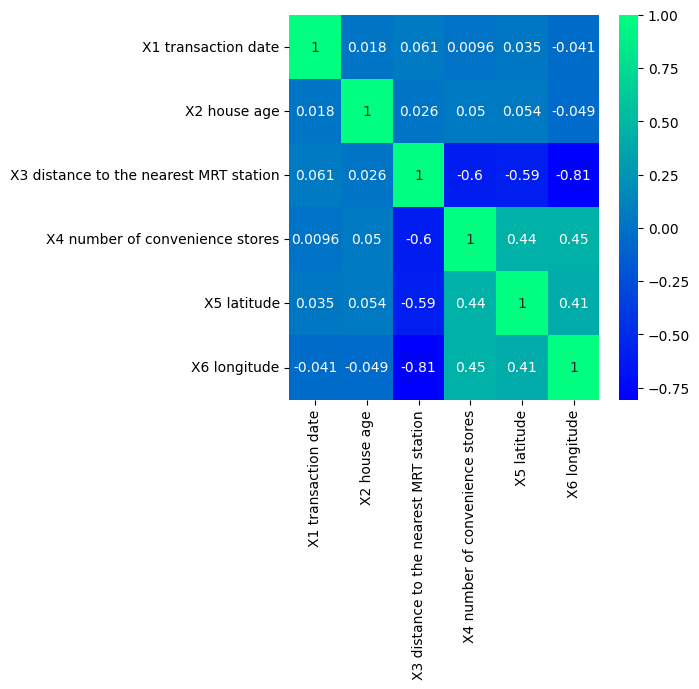

In [ ]:
corr = df.drop(['No', 'Y house price of unit area'], axis=1).corr()
plt.subplots(figsize = (5, 5))
sns.heatmap(corr, annot = True, cmap='winter')

Text(0.5, 9.444444444444438, 'house price of unit area')

<Figure size 1000x400 with 0 Axes>

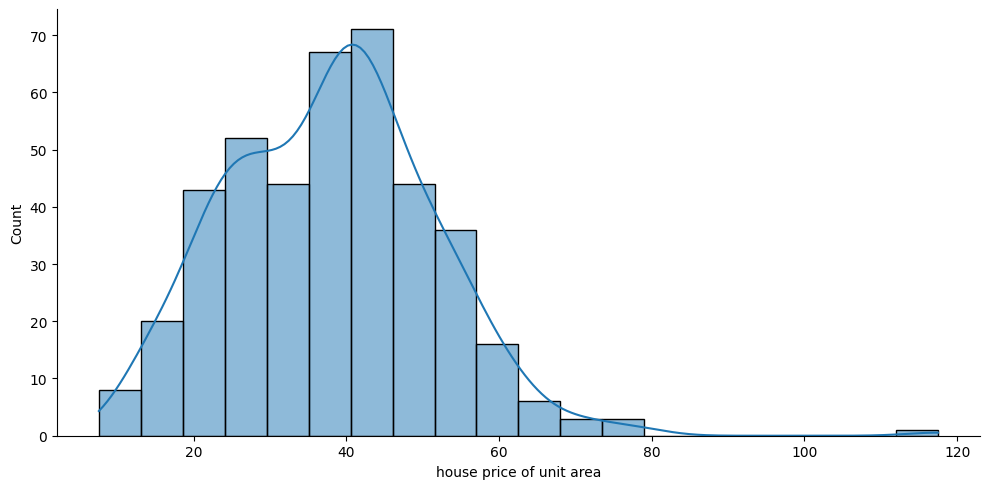

In [ ]:
plt.figure(figsize=(10,4))
sns.displot(df['Y house price of unit area'],kde=True,bins=20, aspect=2)
plt.xlabel('house price of unit area')

<Axes: xlabel='Y house price of unit area'>

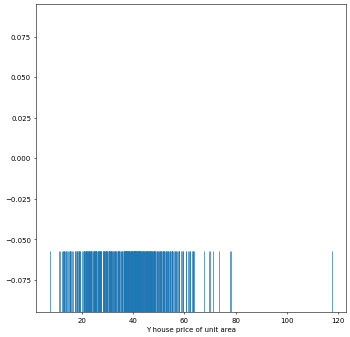

In [ ]:
plt.figure(figsize=(8, 8), dpi=50)

sns.rugplot(df['Y house price of unit area'], height=0.2)

In [ ]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.05,random_state = 0)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit (X_train, y_train)

LinearRegression()

In [ ]:
lr.coef_

array([-3.28281240e-03,  5.18980590e+00, -2.70389960e-01, -4.34076666e-03,
        1.16918512e+00,  2.26156387e+02, -5.63794054e+00])

In [ ]:
y_pred = lr.predict(X_test)
y_pred

array([39.09184855, 12.82614768, 41.76173828, 12.09424855, 41.68156196,
       39.36666405, 40.57898977, 33.8846898 , 50.05358688, 45.550874  ,
       45.51385485, 40.95300388, 38.33135922, 39.89670897, 46.59039145,
       38.21070994, 39.78636257, 40.74697578, 41.30341084, 42.31380145,
       49.36104125])

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print('Linear Regression')
print('RMSE :', mean_squared_error(y_test, y_pred))
print('MAE :', mean_absolute_error(y_test, y_pred))
print('R2 Score :', r2_score(y_test,y_pred)*100)

Linear Regression
RMSE : 33.127369547193794
MAE : 4.5356759061827425
R2 Score : 70.65810721724544


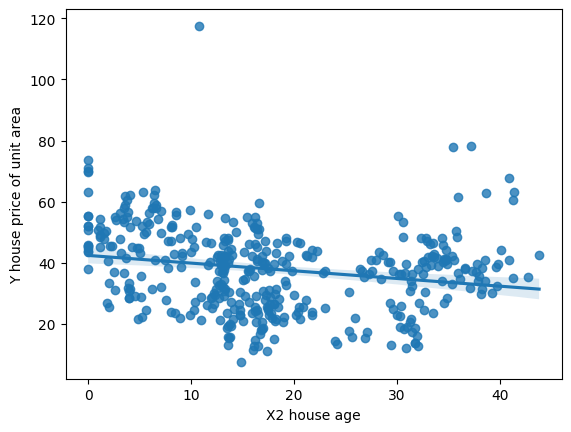

In [ ]:
sns.regplot(x="X2 house age", y="Y house price of unit area", data=df);

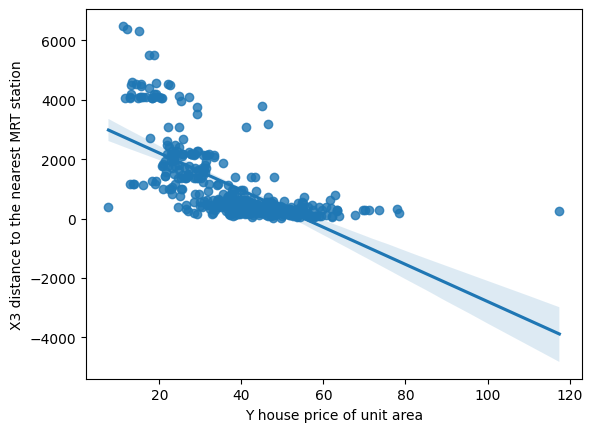

In [ ]:
sns.regplot(y="X3 distance to the nearest MRT station", x="Y house price of unit area", data=df);

In [ ]:
from sklearn.preprocessing import StandardScaler
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
sc=StandardScaler()
X=sc.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.4)

In [ ]:
#Accuracy Using MLP

from sklearn.neural_network import MLPRegressor
regr = MLPRegressor(random_state=1, max_iter=1000).fit(Xtrain, ytrain)
print("Train Accuracy ",regr.score(Xtrain,ytrain)*100)
print("Test Accuracy ",regr.score(Xtest, ytest)*100)

Train Accuracy  76.05099258945425
Test Accuracy  60.32360081924424


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


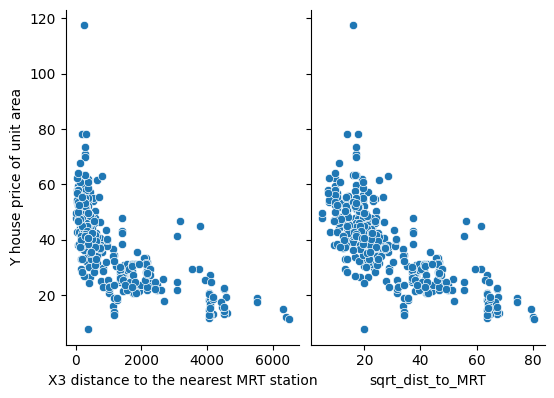

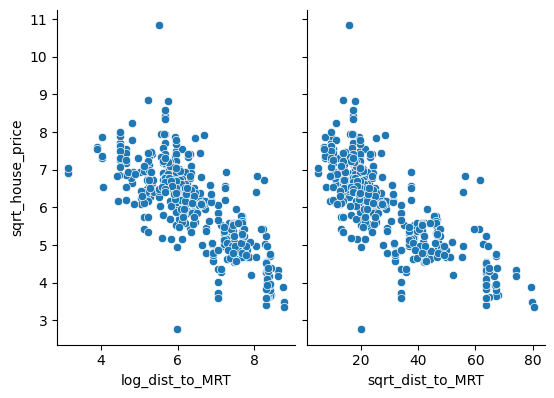

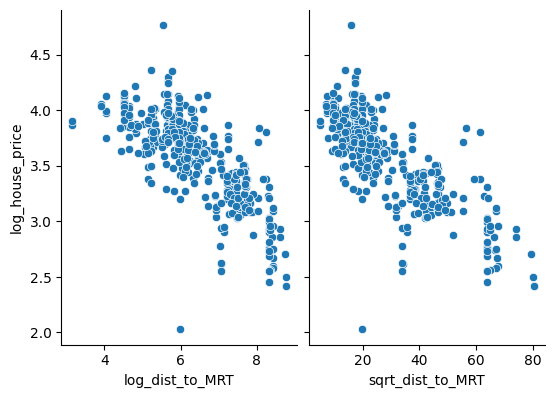

In [ ]:
df['sqrt_dist_to_MRT'] = np.sqrt(df['X3 distance to the nearest MRT station'])
df['sqrt_house_price'] = np.sqrt(df['Y house price of unit area'])
df['log_dist_to_MRT'] = np.log(df['X3 distance to the nearest MRT station'])
df['log_house_price'] = np.log(df['Y house price of unit area'])
p = sns.pairplot(df, x_vars=[ 'X3 distance to the nearest MRT station', 'sqrt_dist_to_MRT'], y_vars= 'Y house price of unit area', size = 4, aspect=0.7)
p = sns.pairplot(df, x_vars=[ 'log_dist_to_MRT', 'sqrt_dist_to_MRT'], y_vars= 'sqrt_house_price', size = 4, aspect=0.7)
p = sns.pairplot(df, x_vars=[ 'log_dist_to_MRT', 'sqrt_dist_to_MRT'], y_vars= 'log_house_price', size = 4, aspect=0.7)

In [ ]:
df_max_scaled=df.copy()
from sklearn import preprocessing
min_max = preprocessing.MinMaxScaler()
scaled_df = min_max.fit_transform(df_max_scaled.values)
#scaled_df.head()
df_scaled = pd.DataFrame(scaled_df)
df_scaled


,0,1,2,3,4,5,6,7,8,9,10,11
0,0.000000,0.272926,0.730594,0.009513,1.0,0.616941,0.719323,0.275705,0.057816,0.420576,0.229166,0.586791
1,0.002421,0.272926,0.445205,0.043809,0.9,0.584949,0.711451,0.314832,0.167400,0.462622,0.457458,0.626037
2,0.004843,1.000000,0.303653,0.083315,0.5,0.671231,0.758896,0.361237,0.249240,0.509801,0.565168,0.667702
3,0.007264,0.909389,0.303653,0.083315,0.5,0.671231,0.758896,0.429481,0.249240,0.574778,0.565168,0.721451
4,0.009685,0.181223,0.114155,0.056799,0.5,0.573194,0.743153,0.323021,0.197156,0.471147,0.500488,0.633744
...,...,...,...,...,...,...,...,...,...,...,...,...
409,0.990315,0.363537,0.312785,0.627820,0.0,0.114881,0.326504,0.070974,0.779989,0.144437,0.917634,0.257905
410,0.992736,0.000000,0.127854,0.010375,0.9,0.512118,0.750162,0.385805,0.061750,0.533749,0.240478,0.687975
411,0.995157,0.636463,0.429224,0.056861,0.7,0.571498,0.715225,0.300273,0.197290,0.447239,0.500671,0.611922
412,0.997579,0.363537,0.184932,0.012596,0.5,0.420141,0.723959,0.408553,0.071350,0.555353,0.266659,0.705793


<Axes: >

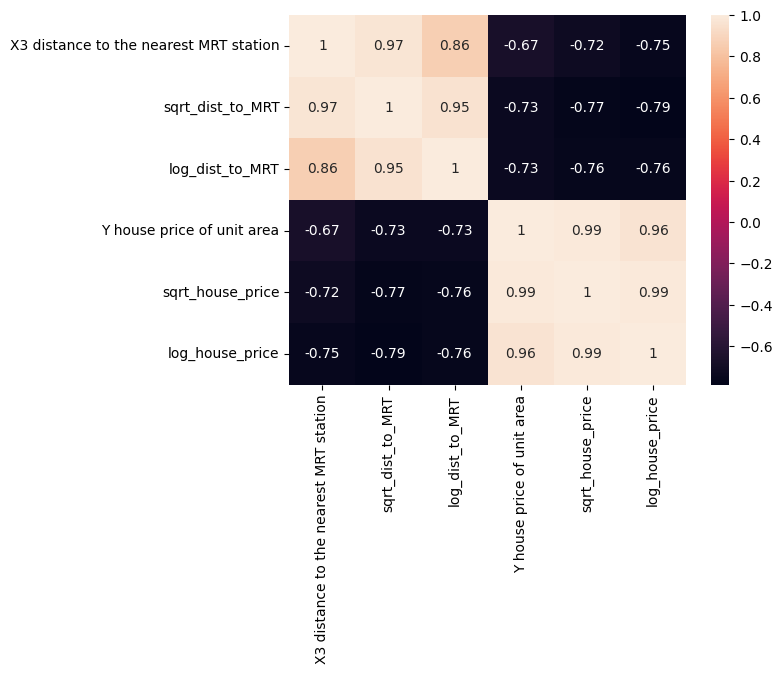

In [ ]:
column = ['X3 distance to the nearest MRT station','sqrt_dist_to_MRT','log_dist_to_MRT','Y house price of unit area','sqrt_house_price','log_house_price']
data=df[column]
data.head()
corr = data.corr("pearson")

sns.heatmap(corr, annot=True)

In [ ]:
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,sqrt_dist_to_MRT,sqrt_house_price,log_dist_to_MRT,log_house_price
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,9.212970,6.156298,4.441225,3.634951
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,17.509846,6.496153,5.725527,3.742420
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,23.706212,6.877500,6.331474,3.856510
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,23.706212,7.402702,6.331474,4.003690
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,19.762803,6.565059,5.967603,3.763523
...,...,...,...,...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4,63.890649,3.924283,8.314346,2.734368
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0,9.510839,7.071068,4.504864,3.912023
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6,19.772951,6.371813,5.968630,3.703768
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5,10.237680,7.245688,4.652150,3.960813


In [ ]:
df_scaled

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.000000,0.272926,0.730594,0.009513,1.0,0.616941,0.719323,0.275705,0.057816,0.420576,0.229166,0.586791
1,0.002421,0.272926,0.445205,0.043809,0.9,0.584949,0.711451,0.314832,0.167400,0.462622,0.457458,0.626037
2,0.004843,1.000000,0.303653,0.083315,0.5,0.671231,0.758896,0.361237,0.249240,0.509801,0.565168,0.667702
3,0.007264,0.909389,0.303653,0.083315,0.5,0.671231,0.758896,0.429481,0.249240,0.574778,0.565168,0.721451
4,0.009685,0.181223,0.114155,0.056799,0.5,0.573194,0.743153,0.323021,0.197156,0.471147,0.500488,0.633744
...,...,...,...,...,...,...,...,...,...,...,...,...
409,0.990315,0.363537,0.312785,0.627820,0.0,0.114881,0.326504,0.070974,0.779989,0.144437,0.917634,0.257905
410,0.992736,0.000000,0.127854,0.010375,0.9,0.512118,0.750162,0.385805,0.061750,0.533749,0.240478,0.687975
411,0.995157,0.636463,0.429224,0.056861,0.7,0.571498,0.715225,0.300273,0.197290,0.447239,0.500671,0.611922
412,0.997579,0.363537,0.184932,0.012596,0.5,0.420141,0.723959,0.408553,0.071350,0.555353,0.266659,0.705793


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


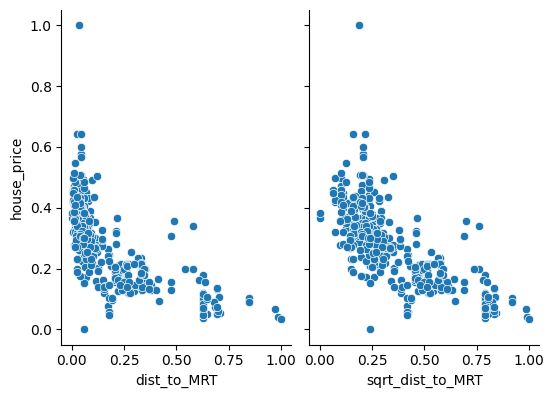

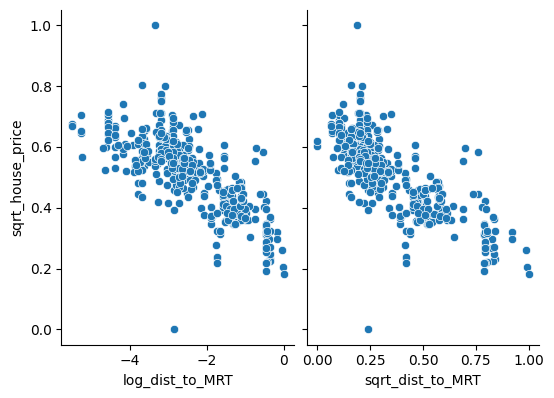

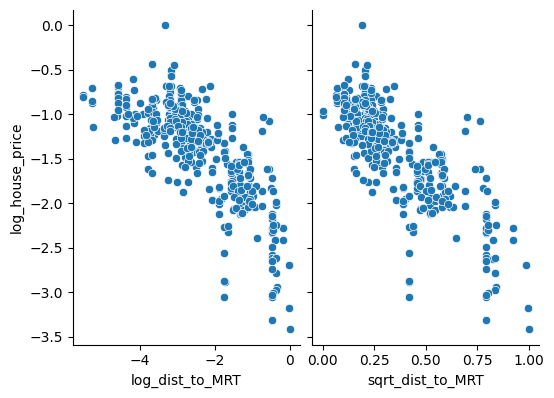

In [ ]:
new_names = ['No','trans_date','house_age','dist_to_MRT','conv_store','lat','long','house_price','sqrt_dist_to_MRT', 'sqrt_house_price', 'log_dist_to_MRT', 'log_house_price']
df_scaled = df_scaled.set_axis(new_names, axis='columns')
df_scaled['sqrt_dist_to_MRT'] = np.sqrt(df_scaled.dist_to_MRT)
df_scaled['sqrt_house_price'] = np.sqrt(df_scaled.house_price)
df_scaled['log_dist_to_MRT'] = np.log(df_scaled.dist_to_MRT)
df_scaled['log_house_price'] = np.log(df_scaled.house_price)
p = sns.pairplot(df_scaled, x_vars=['dist_to_MRT','sqrt_dist_to_MRT'], y_vars='house_price', size=4, aspect=0.7)
p = sns.pairplot(df_scaled, x_vars=['log_dist_to_MRT','sqrt_dist_to_MRT'], y_vars='sqrt_house_price', size=4, aspect=0.7)
p = sns.pairplot(df_scaled, x_vars=['log_dist_to_MRT','sqrt_dist_to_MRT'], y_vars='log_house_price', size=4, aspect=0.7)

<Axes: >

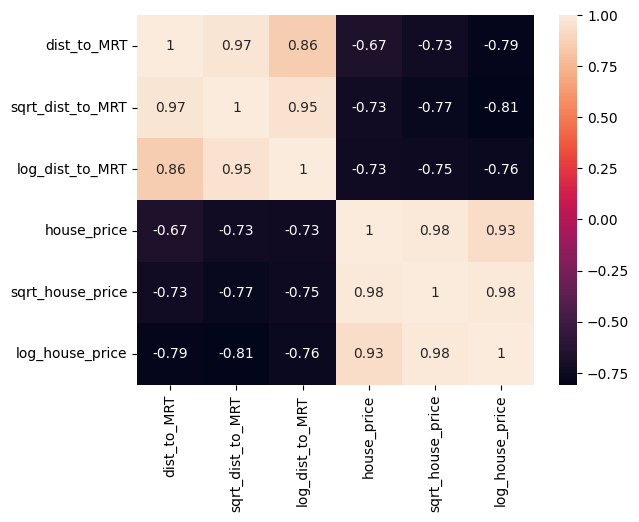

In [ ]:
column = ['dist_to_MRT','sqrt_dist_to_MRT','log_dist_to_MRT','house_price','sqrt_house_price','log_house_price']
data = df_scaled[column]
data.head()
corr = data.corr("pearson")

sns.heatmap(corr, annot=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
 8   sqrt_dist_to_MRT                        414 non-null    float64
 9   sqrt_house_price                        414 non-null    float64
 10  log_dist_to_MRT                         414 non-null    float6

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean Squared Error: 40.00760462338116
Mean Absolute Error: 4.6083107528671245
R-squared Score: 0.7753886691362429



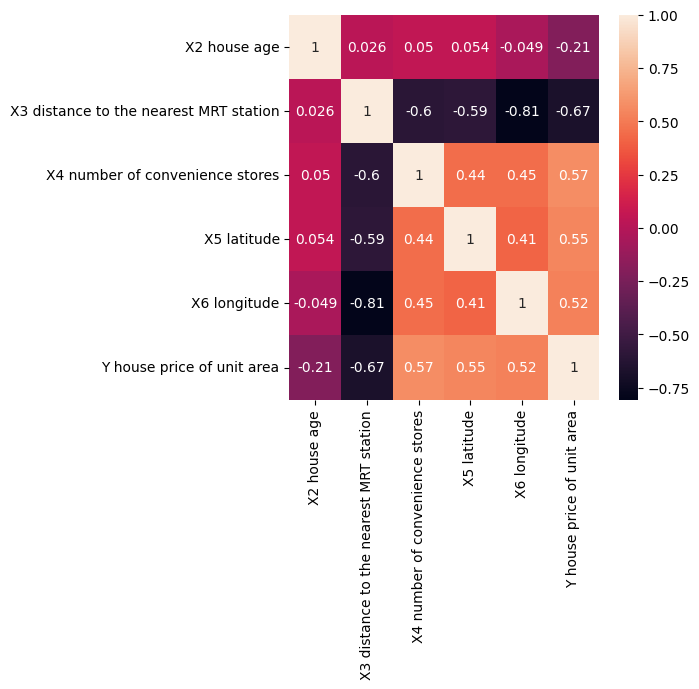

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

df.info()
corr = df.drop(['No','X1 transaction date','sqrt_dist_to_MRT', 'sqrt_house_price',	'log_dist_to_MRT', 'log_house_price'],axis=1).corr()
plt.subplots(figsize = (5,5))
sns.heatmap(corr, annot = True)

# Bagi data Anda menjadi set pelatihan dan pengujian
X = df.drop(['No','X1 transaction date','Y house price of unit area','sqrt_dist_to_MRT', 'sqrt_house_price',	'log_dist_to_MRT', 'log_house_price'],axis=1)
Y = df.iloc[:,-5]
sc=StandardScaler()
X=sc.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Tentukan parameter hiperparameter jaringan saraf Anda
params = {
    'hidden_layer_sizes': (3,2),  # Sesuaikan jumlah neuron di setiap lapisan tersembunyi
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,  # Kekuatan regularisasi
    'batch_size': 10,
    'random_state': 0,
    'tol': 1e-4,
    'momentum': 0.9,  # Momentum
    'learning_rate': 'constant',
    'learning_rate_init': 0.01,
    'max_iter': 50,
    'shuffle': True,
    'n_iter_no_change': 50,
    'verbose': False
}

# Buat MLPRegressor
print("\nMembuat neural network dengan aktivasi relu")
net = MLPRegressor(**params)

# Latih NN pada data training
net.fit(X_train, Y_train)

# Lakukan prediksi pada data test
Y_pred_net = net.predict(X_test)

# Evaluasi kinerja model
mse = mean_squared_error(Y_test, Y_pred_net)
mae = mean_absolute_error(Y_test, Y_pred_net)
r2 = r2_score(Y_test, Y_pred_net)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared Score: {r2}\n")


In [ ]:
Y

0      37.9
1      42.2
2      47.3
3      54.8
4      43.1
       ... 
409    15.4
410    50.0
411    40.6
412    52.5
413    63.9
Name: Y house price of unit area, Length: 414, dtype: float64

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Ganti path dengan direktori yang Anda inginkan
directory = "/content/drive/MyDrive/YourDirectory"

if not os.path.exists(directory):
    os.makedirs(directory)

import pickle
print("Saving")
path = "/content/drive/MyDrive/YourDirectory/realestate.sav"
pickle.dump(net, open(path, "wb"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving
